# VIX ETN Dual Strategy — Replication of Zarattini, Mele & Aziz (2025)## "The Volatility Edge: A Dual Approach for VIX ETNs Trading"**Paper:** SFI Research Paper N°25-91 (Swiss Finance Institute)**Strategy progression:**1. **Passive** — constant 20% short-vol allocation2. **eVRP** — time entry using expected volatility risk premium3. **eVRP + BoC** — add VIX term structure (contango/backwardation) signal4. **eVRP + BoC + Sizing** — dynamic position sizing based on VIX level**Data sources:**- SPY, SVXY, VXX → Alpaca (tradable instruments)- VIX → FRED CSV (VIXCLS)- VIX3M → CBOE CSV (VIX3M_History)**Key implementation notes:**- SVXY is -0.5x leverage; paper assumes -1x (VIXSHORT proxy). We construct a synthetic -1x return series.- eRV30 = 10-day rolling std of SPY returns × √252 × 100- Signals computed on close (paper uses 3:45pm; daily close is a reasonable approximation)- 5 bps transaction cost per trade, ±2% rebalancing threshold

In [60]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.metrics import evaluate_strategy, print_metrics
from _shared.plotting import plot_equity_curve, plot_trade_returns, plot_yearly_returns
from _shared.significance import full_significance_report, print_significance_report
from _shared.results import save_trades

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [61]:
# =============================================================================
# CONFIGURATION
# =============================================================================

SYMBOLS = ["SPY", "SVXY", "VXX"]
START_DATE = "2009-10-01"   # VIX3M data starts Sep 2009
END_DATE = "2026-04-01"
STARTING_CAPITAL = 100_000
STRATEGY_NAME = "VIX ETN Dual"
SAVE_NAME = "vix_etn_dual"

# Paper parameters
REALIZED_VOL_WINDOW = 10          # 10-day rolling std for eRV30
TCOST_BPS = 5                     # 5 bps per trade
REBALANCE_THRESHOLD = 0.02        # ±2% drift threshold
ANNUAL_FEE_SHORT = 0.0080         # 80 bps annual fee for short-vol proxy
ANNUAL_FEE_LONG = 0.0050          # 50 bps annual fee for long-vol proxy

# VIX data paths (local CSVs)
VIX_CSV = "VIXCLS.csv"
VIX3M_CSV = "VIX3M_History.csv" 

In [62]:
# =============================================================================
# DATA FETCHING
# =============================================================================

# ── 1. Alpaca: SPY, SVXY, VXX ──
data_dict = fetch_historical_data(SYMBOLS, TimeFrame(1, TimeFrameUnit.Day), START_DATE, END_DATE)

frames = {}
for sym in SYMBOLS:
    d = data_dict[sym].copy()
    if d.index.tz is None:
        d.index = d.index.tz_localize("UTC").tz_convert("US/Eastern")
    else:
        d.index = d.index.tz_convert("US/Eastern")
    d = d.reset_index()
    d["date"] = d["timestamp"].dt.date
    d = d.groupby("date").last().reset_index()
    d["date"] = pd.to_datetime(d["date"])
    frames[sym] = d[["date", "close"]].rename(columns={"close": sym.lower()})
    frames[sym] = frames[sym].sort_values("date").reset_index(drop=True)
    print(f"{sym}: {len(frames[sym]):,} bars  ({frames[sym]['date'].iloc[0].date()} → {frames[sym]['date'].iloc[-1].date()})")

# ── 2. VIX from FRED CSV ──
vix_raw = pd.read_csv(VIX_CSV)
vix_raw.columns = vix_raw.columns.str.strip()
vix_raw = vix_raw.rename(columns={"observation_date": "date", "VIXCLS": "vix"})
vix_raw["date"] = pd.to_datetime(vix_raw["date"])
vix_raw["vix"] = pd.to_numeric(vix_raw["vix"], errors="coerce")
vix_raw = vix_raw.dropna(subset=["vix"]).reset_index(drop=True)
print(f"VIX:  {len(vix_raw):,} bars  ({vix_raw['date'].iloc[0].date()} → {vix_raw['date'].iloc[-1].date()})")

# ── 3. VIX3M from CBOE CSV ──
vix3m_raw = pd.read_csv(VIX3M_CSV)
vix3m_raw.columns = vix3m_raw.columns.str.strip()
vix3m_raw = vix3m_raw.rename(columns={"DATE": "date", "CLOSE": "vix3m"})
vix3m_raw["date"] = pd.to_datetime(vix3m_raw["date"], format="mixed")
vix3m_raw["vix3m"] = pd.to_numeric(vix3m_raw["vix3m"], errors="coerce")
vix3m_raw = vix3m_raw[["date", "vix3m"]].dropna().reset_index(drop=True)
print(f"VIX3M: {len(vix3m_raw):,} bars  ({vix3m_raw['date'].iloc[0].date()} → {vix3m_raw['date'].iloc[-1].date()})")

Fetching SPY...
  2,575 bars
Fetching SVXY...
  2,575 bars
Fetching VXX...
  2,061 bars
SPY: 2,575 bars  (2016-01-04 → 2026-03-31)
SVXY: 2,575 bars  (2016-01-04 → 2026-03-31)
VXX: 2,061 bars  (2018-01-18 → 2026-03-31)
VIX:  9,157 bars  (1990-01-02 → 2026-04-02)
VIX3M: 4,160 bars  (2009-09-18 → 2026-04-02)


In [63]:
# =============================================================================
# MERGE & BUILD SYNTHETIC PROXIES
# =============================================================================

# Merge all on date
df = frames["SPY"].copy()
for sym in ["SVXY", "VXX"]:
    df = df.merge(frames[sym.upper()], on="date", how="inner")
df = df.merge(vix_raw[["date", "vix"]], on="date", how="inner")
df = df.merge(vix3m_raw[["date", "vix3m"]], on="date", how="inner")
df = df.sort_values("date").reset_index(drop=True)
print(f"Merged: {len(df):,} bars  ({df['date'].iloc[0].date()} → {df['date'].iloc[-1].date()})")

# ── Build VIXSHORT proxy (synthetic -1x from SVXY) ──
# SVXY is -0.5x leverage. To get -1x daily returns:
#   r_vixshort = 2 × r_svxy  (doubling the daily return)
# Then subtract annual fee of 80 bps / 252 per day
df["svxy_ret"] = df["svxy"].pct_change()
df["vixshort_ret"] = 2 * df["svxy_ret"] - (ANNUAL_FEE_SHORT / 252)

# Build VIXSHORT price series (cumulative from $100)
df["vixshort"] = 100 * (1 + df["vixshort_ret"]).cumprod()
df.loc[0, "vixshort"] = 100  # seed

# ── Build VIXLONG proxy (from VXX) ──
# VXX is already 1x long vol. Subtract annual fee of 50 bps / 252
df["vxx_ret"] = df["vxx"].pct_change()
df["vixlong_ret"] = df["vxx_ret"] - (ANNUAL_FEE_LONG / 252)

# Build VIXLONG price series
df["vixlong"] = 100 * (1 + df["vixlong_ret"]).cumprod()
df.loc[0, "vixlong"] = 100

print(f"\nVIXSHORT range: {df['vixshort'].iloc[-1]:.2f} (from 100)")
print(f"VIXLONG range:  {df['vixlong'].iloc[-1]:.4f} (from 100)")
print(f"\nSample:")
print(df[["date", "spy", "svxy", "vxx", "vix", "vix3m", "vixshort", "vixlong"]].tail(5).to_string(index=False))

Merged: 2,061 bars  (2018-01-18 → 2026-03-31)

VIXSHORT range: -11.75 (from 100)
VIXLONG range:  1.9641 (from 100)

Sample:
      date    spy  svxy   vxx   vix  vix3m   vixshort  vixlong
2026-03-25 656.82 47.02 34.25 25.33  25.63 -12.454714 1.884457
2026-03-26 645.09 45.19 36.62 27.44  27.16 -11.484853 2.014818
2026-03-27 634.09 43.44 39.41 31.05  29.27 -10.594978 2.168283
2026-03-30 631.97 43.66 39.16 30.61  29.13 -10.701957 2.154486
2026-03-31 650.34 45.80 35.70 25.25  25.55 -11.750733 1.964082


In [64]:
# =============================================================================
# SIGNAL CONSTRUCTION
# =============================================================================

# ── Signal 1: Expected Volatility Risk Premium (eVRP) ──
# eRV30 = 10-day rolling std of SPY daily returns, annualized
df["spy_ret"] = df["spy"].pct_change()
df["eRV30"] = df["spy_ret"].rolling(REALIZED_VOL_WINDOW).std() * np.sqrt(252) * 100
df["eVRP"] = df["vix"] - df["eRV30"]

# ── Signal 2: VIX Term Structure (Contango/Backwardation) ──
# Contango: VIX < VIX3M (normal, calm markets)
# Backwardation: VIX > VIX3M (stress)
df["contango"] = df["vix"] < df["vix3m"]
df["backwardation"] = df["vix"] > df["vix3m"]

# Drop warmup rows
df = df.dropna(subset=["eRV30"]).reset_index(drop=True)

print(f"Signal coverage: {len(df):,} days")
print(f"\neVRP > 0 (VRP positive):     {(df['eVRP'] > 0).mean()*100:.1f}%")
print(f"Contango (VIX < VIX3M):      {df['contango'].mean()*100:.1f}%")
print(f"Backwardation (VIX > VIX3M): {df['backwardation'].mean()*100:.1f}%")
print(f"\neVRP > 0 AND Contango:       {((df['eVRP'] > 0) & df['contango']).mean()*100:.1f}%")
print(f"eVRP < 0 AND Contango:       {((df['eVRP'] <= 0) & df['contango']).mean()*100:.1f}%")
print(f"eVRP < 0 AND Backwardation:  {((df['eVRP'] <= 0) & df['backwardation']).mean()*100:.1f}%")

Signal coverage: 2,051 days

eVRP > 0 (VRP positive):     82.9%
Contango (VIX < VIX3M):      91.1%
Backwardation (VIX > VIX3M): 8.9%

eVRP > 0 AND Contango:       77.8%
eVRP < 0 AND Contango:       13.3%
eVRP < 0 AND Backwardation:  3.8%


In [65]:
# =============================================================================
# STRATEGY DEFINITIONS (from paper Table 2)
# =============================================================================
#
# Each strategy function returns for each day:
#   instrument: "vixshort", "vixlong", or "cash"
#   target_weight: float (fraction of portfolio)
#
# Strategy 1 (Passive):     Always 20% VIXSHORT
# Strategy 2 (eVRP):        20% VIXSHORT if eVRP > 0, else cash
# Strategy 3 (eVRP+BoC):    20% VIXSHORT if eVRP>0 & contango
#                           10% VIXSHORT if eVRP<=0 & contango
#                           20% VIXLONG  if eVRP<=0 & backwardation
#                           else cash
# Strategy 4 (eVRP+BoC+Sizing): Same signals as 3, but size = VIX/100
#                           (or 0.5×VIX/100 for medium conviction)

def strategy_passive(row):
    return "vixshort", 0.20

def strategy_evrp(row):
    if row["eVRP"] > 0:
        return "vixshort", 0.20
    return "cash", 0.0

def strategy_evrp_boc(row):
    if row["eVRP"] > 0 and row["contango"]:
        return "vixshort", 0.20
    elif row["eVRP"] <= 0 and row["contango"]:
        return "vixshort", 0.10
    elif row["eVRP"] <= 0 and row["backwardation"]:
        return "vixlong", 0.20
    return "cash", 0.0

def strategy_evrp_boc_sizing(row):
    vix_pct = row["vix"] / 100.0  # VIX=20 → 20% allocation
    if row["eVRP"] > 0 and row["contango"]:
        return "vixshort", vix_pct
    elif row["eVRP"] <= 0 and row["contango"]:
        return "vixshort", 0.5 * vix_pct
    elif row["eVRP"] <= 0 and row["backwardation"]:
        return "vixlong", vix_pct
    return "cash", 0.0

STRATEGIES = {
    "Passive":          strategy_passive,
    "eVRP":             strategy_evrp,
    "eVRP+BoC":         strategy_evrp_boc,
    "eVRP+BoC+Sizing":  strategy_evrp_boc_sizing,
}

print("Strategy definitions loaded.")

Strategy definitions loaded.


In [66]:
# =============================================================================
# BACKTESTER ENGINE
# =============================================================================
# This is a portfolio-level backtester (not per-trade).
# The strategy holds a fractional allocation to VIXSHORT or VIXLONG,
# rebalancing only when drift exceeds the threshold.
#
# Returns a daily equity series for each strategy.

def run_backtest(df, strategy_fn, starting_capital=100_000,
                 rebal_threshold=0.02, tcost_bps=5):
    """
    Run a portfolio-level backtest.
    
    Parameters
    ----------
    df : DataFrame with columns: date, vixshort_ret, vixlong_ret, eVRP, contango, backwardation, vix
    strategy_fn : function(row) → (instrument, target_weight)
    
    Returns
    -------
    dict with daily equity series and trade log
    """
    tcost_rate = tcost_bps / 10000.0
    
    n = len(df)
    equity = np.zeros(n)
    equity[0] = starting_capital
    
    # Track current allocation
    current_instrument = "cash"  # "vixshort", "vixlong", or "cash"
    current_weight = 0.0          # actual weight in the instrument
    
    trades = []
    n_rebalances = 0
    
    # Daily positions tracking
    daily_log = []
    
    for i in range(n):
        row = df.iloc[i]
        
        if i == 0:
            equity[i] = starting_capital
            # Get initial signal
            target_instrument, target_weight = strategy_fn(row)
            current_instrument = target_instrument
            current_weight = target_weight
            
            # Pay transaction cost on initial entry
            if current_weight > 0:
                cost = equity[i] * current_weight * tcost_rate
                equity[i] -= cost
                n_rebalances += 1
            
            daily_log.append({
                "date": row["date"],
                "equity": equity[i],
                "instrument": current_instrument,
                "weight": current_weight,
                "vix": row["vix"],
                "eVRP": row["eVRP"],
            })
            continue
        
        # ── Step 1: Apply today's return to current position ──
        if current_instrument == "vixshort" and current_weight > 0:
            instrument_ret = row["vixshort_ret"]
        elif current_instrument == "vixlong" and current_weight > 0:
            instrument_ret = row["vixlong_ret"]
        else:
            instrument_ret = 0.0
        
        # Portfolio return: weight × instrument_ret + (1 - weight) × 0
        # (cash earns 0 — conservative, matching paper)
        if not np.isnan(instrument_ret):
            port_ret = current_weight * instrument_ret
            equity[i] = equity[i-1] * (1 + port_ret)
        else:
            equity[i] = equity[i-1]
        
        # Update actual weight after return (drift)
        if current_weight > 0 and not np.isnan(instrument_ret):
            # New weight = old_notional × (1+r) / new_equity
            current_weight = current_weight * (1 + instrument_ret) / (1 + port_ret)
        
        # ── Step 2: Check signal and rebalance if needed ──
        target_instrument, target_weight = strategy_fn(row)
        
        needs_rebalance = False
        
        # Instrument change → always rebalance
        if target_instrument != current_instrument:
            needs_rebalance = True
        # Same instrument but weight drifted beyond threshold
        elif abs(current_weight - target_weight) > rebal_threshold:
            needs_rebalance = True
        
        if needs_rebalance:
            # Transaction cost on the turnover
            turnover = abs(current_weight - target_weight)
            if target_instrument != current_instrument:
                # Closing old + opening new
                turnover = current_weight + target_weight
            
            cost = equity[i] * turnover * tcost_rate
            equity[i] -= cost
            
            trades.append({
                "date": row["date"],
                "from_instrument": current_instrument,
                "from_weight": round(current_weight, 4),
                "to_instrument": target_instrument,
                "to_weight": round(target_weight, 4),
                "turnover": round(turnover, 4),
                "cost": round(cost, 2),
                "equity": round(equity[i], 2),
                "vix": row["vix"],
            })
            
            current_instrument = target_instrument
            current_weight = target_weight
            n_rebalances += 1
        
        daily_log.append({
            "date": row["date"],
            "equity": equity[i],
            "instrument": current_instrument,
            "weight": current_weight,
            "vix": row["vix"],
            "eVRP": row["eVRP"],
        })
    
    daily_df = pd.DataFrame(daily_log)
    trades_df = pd.DataFrame(trades)
    
    return {
        "equity": equity,
        "daily": daily_df,
        "trades": trades_df,
        "n_rebalances": n_rebalances,
    }


def compute_metrics(daily_df, starting_capital, name="Strategy"):
    """Compute performance metrics from daily equity series."""
    eq = daily_df["equity"].values
    dates = daily_df["date"].values
    
    # Daily returns
    rets = np.diff(eq) / eq[:-1]
    rets = rets[~np.isnan(rets)]
    
    total_ret = (eq[-1] / eq[0]) - 1
    n_years = (pd.to_datetime(dates[-1]) - pd.to_datetime(dates[0])).days / 365.25
    cagr = (eq[-1] / eq[0]) ** (1/n_years) - 1
    vol = np.std(rets) * np.sqrt(252)
    sharpe = (cagr / vol) if vol > 0 else 0
    sortino_denom = np.std(rets[rets < 0]) * np.sqrt(252) if (rets < 0).any() else 1
    sortino = cagr / sortino_denom if sortino_denom > 0 else 0
    
    # Max drawdown
    running_max = np.maximum.accumulate(eq)
    drawdowns = (eq - running_max) / running_max
    max_dd = drawdowns.min()
    
    # SPY correlation (using daily returns)
    spy_rets = df["spy"].pct_change().iloc[-len(rets):].values
    if len(spy_rets) == len(rets):
        mask = ~(np.isnan(spy_rets) | np.isnan(rets))
        corr = np.corrcoef(rets[mask], spy_rets[mask])[0, 1] if mask.sum() > 10 else 0
    else:
        corr = 0
    
    # Beta and Alpha
    if len(spy_rets) == len(rets):
        mask = ~(np.isnan(spy_rets) | np.isnan(rets))
        if mask.sum() > 10:
            cov_matrix = np.cov(rets[mask], spy_rets[mask])
            beta = cov_matrix[0, 1] / cov_matrix[1, 1] if cov_matrix[1, 1] > 0 else 0
            spy_annual = (1 + spy_rets[mask].mean()) ** 252 - 1
            alpha = cagr - beta * spy_annual
        else:
            beta, alpha = 0, cagr
    else:
        beta, alpha = 0, cagr
    
    # Position breakdown
    pct_short = (daily_df["instrument"] == "vixshort").mean() * 100
    pct_long = (daily_df["instrument"] == "vixlong").mean() * 100
    pct_cash = (daily_df["instrument"] == "cash").mean() * 100
    avg_weight = daily_df["weight"].mean() * 100
    
    # Yearly returns
    daily_df_copy = daily_df.copy()
    daily_df_copy["year"] = pd.to_datetime(daily_df_copy["date"]).dt.year
    yearly = {}
    for year, grp in daily_df_copy.groupby("year"):
        yr_ret = grp["equity"].iloc[-1] / grp["equity"].iloc[0] - 1
        yearly[year] = round(yr_ret * 100, 2)
    
    return {
        "Strategy": name,
        "TotRet (%)": round(total_ret * 100, 2),
        "CAGR (%)": round(cagr * 100, 2),
        "Vol (%)": round(vol * 100, 2),
        "Sharpe": round(sharpe, 2),
        "Sortino": round(sortino, 2),
        "MDD (%)": round(max_dd * 100, 2),
        "Alpha (%)": round(alpha * 100, 2),
        "Beta": round(beta, 2),
        "Corr SPX (%)": round(corr * 100, 2),
        "% Short Vol": round(pct_short, 1),
        "% Long Vol": round(pct_long, 1),
        "% Cash": round(pct_cash, 1),
        "Avg Exposure (%)": round(avg_weight, 1),
        "Trades": len(daily_df_copy) if "trades" not in dir() else 0,
        "Final Equity": round(eq[-1], 2),
        "Yearly Returns": yearly,
    }

print("Backtester engine loaded.")

Backtester engine loaded.


In [67]:
# =============================================================================
# RUN ALL 4 STRATEGIES
# =============================================================================

results = {}
metrics_list = []

for name, fn in STRATEGIES.items():
    print(f"\n{'='*60}")
    print(f"Running: {name}")
    print(f"{'='*60}")
    
    res = run_backtest(df, fn, starting_capital=STARTING_CAPITAL,
                       rebal_threshold=REBALANCE_THRESHOLD, tcost_bps=TCOST_BPS)
    results[name] = res
    
    m = compute_metrics(res["daily"], STARTING_CAPITAL, name=name)
    m["Rebalances"] = res["n_rebalances"]
    m["Trades/yr"] = round(res["n_rebalances"] / 
        ((pd.to_datetime(df["date"].iloc[-1]) - pd.to_datetime(df["date"].iloc[0])).days / 365.25), 1)
    metrics_list.append(m)
    
    print(f"  CAGR:    {m['CAGR (%)']:.1f}%")
    print(f"  Sharpe:  {m['Sharpe']:.2f}")
    print(f"  MDD:     {m['MDD (%)']:.1f}%")
    print(f"  Alpha:   {m['Alpha (%)']:.1f}%")
    print(f"  Beta:    {m['Beta']:.2f}")
    print(f"  Corr:    {m['Corr SPX (%)']:.1f}%")
    print(f"  Rebal:   {m['Rebalances']} ({m['Trades/yr']}/yr)")
    print(f"  Final:   ${m['Final Equity']:,.2f}")


Running: Passive
  CAGR:    -2.5%
  Sharpe:  -0.12
  MDD:     -54.9%
  Alpha:   -11.6%
  Beta:    0.63
  Corr:    59.5%
  Rebal:   167 (20.5/yr)
  Final:   $81,657.10

Running: eVRP
  CAGR:    -2.4%
  Sharpe:  -0.13
  MDD:     -50.2%
  Alpha:   -8.7%
  Beta:    0.43
  Corr:    44.4%
  Rebal:   259 (31.7/yr)
  Final:   $81,965.76

Running: eVRP+BoC
  CAGR:    6.1%
  Sharpe:  0.46
  MDD:     -15.6%
  Alpha:   2.6%
  Beta:    0.24
  Corr:    34.4%
  Rebal:   339 (41.6/yr)
  Final:   $161,874.07

Running: eVRP+BoC+Sizing
  CAGR:    11.6%
  Sharpe:  0.61
  MDD:     -32.5%
  Alpha:   10.3%
  Beta:    0.09
  Corr:    8.8%
  Rebal:   695 (85.2/yr)
  Final:   $243,907.51


In [68]:
# =============================================================================
# COMPARISON TABLE (replicating paper Table 3)
# =============================================================================

compare_cols = ["Strategy", "TotRet (%)", "CAGR (%)", "Vol (%)", "Sharpe", "Sortino",
                "MDD (%)", "Alpha (%)", "Beta", "Corr SPX (%)",
                "% Short Vol", "% Long Vol", "% Cash", "Avg Exposure (%)",
                "Rebalances", "Trades/yr"]

compare_df = pd.DataFrame([{k: m[k] for k in compare_cols if k in m} for m in metrics_list])
compare_df = compare_df.set_index("Strategy")
print("\n" + "="*80)
print("STRATEGY COMPARISON (replicating paper Table 3)")
print("="*80)
print(compare_df.to_string())

# Paper reference values (Table 3):
print("\n--- Paper Reference (2008-2025) ---")
print("             CAGR   Sharpe   MDD      Alpha   Beta   Corr")
print("Passive       6.2%   0.48   -32.0%    0.8%   0.53   71.6%")
print("eVRP          6.9%   0.56   -23.5%    2.9%   0.39   58.7%")
print("eVRP+BoC     10.5%   0.87   -15.2%    8.1%   0.22   35.4%")
print("eVRP+BoC+Sz  16.3%   1.00   -31.0%   15.0%   0.12   14.8%")


STRATEGY COMPARISON (replicating paper Table 3)
                 TotRet (%)  CAGR (%)  Vol (%)  Sharpe  Sortino  MDD (%)  Alpha (%)  Beta  Corr SPX (%)  % Short Vol  % Long Vol  % Cash  Avg Exposure (%)  Rebalances  Trades/yr
Strategy                                                                                                                                                                         
Passive              -18.33     -2.45    20.16   -0.12    -0.10   -54.91     -11.62  0.63         59.46        100.0         0.0     0.0              20.3         167       20.5
eVRP                 -18.03     -2.41    18.44   -0.13    -0.10   -50.19      -8.67  0.43         44.41         82.9         0.0    17.1              16.8         259       31.7
eVRP+BoC              61.89      6.08    13.20    0.46     0.52   -15.64       2.61  0.24         34.39         91.1         3.8     5.1              17.9         339       41.6
eVRP+BoC+Sizing      143.92     11.55    18.89    0.61     0.

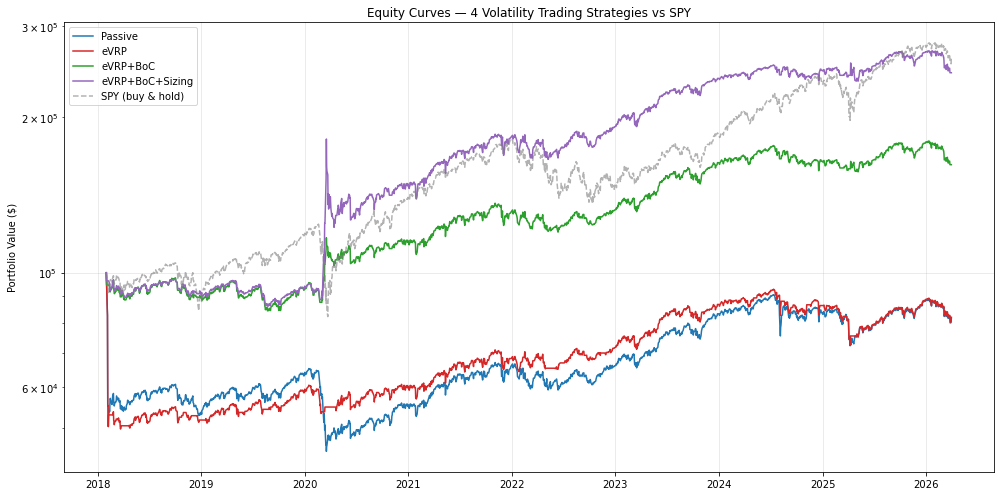

In [69]:
# =============================================================================
# EQUITY CURVES (replicating paper Figure 4)
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 7))

colors = {"Passive": "#1f77b4", "eVRP": "#d62728", 
          "eVRP+BoC": "#2ca02c", "eVRP+BoC+Sizing": "#9467bd"}

for name, res in results.items():
    daily = res["daily"]
    dates = pd.to_datetime(daily["date"]).values
    equity = daily["equity"].values
    ax.plot(dates, equity, label=name, color=colors.get(name, "gray"), linewidth=1.5)

# Add SPY buy-and-hold for reference
spy_equity = STARTING_CAPITAL * (df["spy"] / df["spy"].iloc[0])
ax.plot(pd.to_datetime(df["date"]).values, spy_equity.values, 
        label="SPY (buy & hold)", color="gray", linestyle="--", alpha=0.6)

ax.set_yscale("log")
ax.set_ylabel("Portfolio Value ($)")
ax.set_title("Equity Curves — 4 Volatility Trading Strategies vs SPY")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [70]:
# =============================================================================
# YEARLY RETURNS (replicating paper Table 4 / Appendix B)
# =============================================================================

yearly_data = {}
for m in metrics_list:
    yearly_data[m["Strategy"]] = m["Yearly Returns"]

# Add SPY
spy_yearly = {}
df_copy = df.copy()
df_copy["year"] = pd.to_datetime(df_copy["date"]).dt.year
for year, grp in df_copy.groupby("year"):
    spy_yearly[year] = round((grp["spy"].iloc[-1] / grp["spy"].iloc[0] - 1) * 100, 2)
yearly_data["SPY"] = spy_yearly

yearly_df = pd.DataFrame(yearly_data)
print("\nYEARLY RETURNS (%)")
print("="*80)
print(yearly_df.to_string())


YEARLY RETURNS (%)
      Passive   eVRP  eVRP+BoC  eVRP+BoC+Sizing    SPY
2018   -46.60 -48.15    -10.34            -8.76  -9.93
2019    18.27  13.76      4.50             3.23  31.06
2020   -13.38   1.38     22.70            57.78  17.39
2021    21.04  15.36     16.00            26.02  30.46
2022    -0.80   4.15      0.03             3.94 -18.64
2023    25.90  21.02     23.29            23.82  26.72
2024     0.21  -0.48      0.49             3.55  25.59
2025     6.20   2.52      9.00             8.78  18.01
2026    -7.74  -7.74     -9.62            -9.00  -4.54


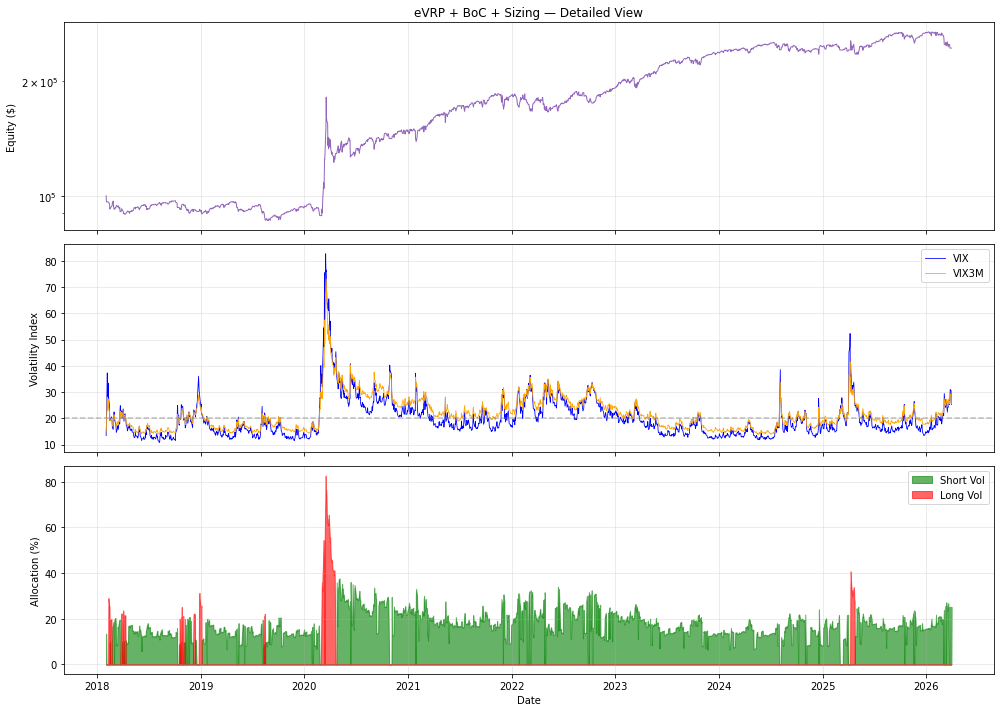


Total rebalances: 694
Total transaction costs: $4,772.19

Rebalance log (last 10):
      date from_instrument  from_weight to_instrument  to_weight  turnover  cost    equity   vix
2026-03-10            cash       0.0000      vixshort     0.2493    0.2493 31.08 249313.17 24.93
2026-03-12        vixshort       0.2441          cash     0.0000    0.2441 30.22 247565.99 27.29
2026-03-13            cash       0.0000      vixshort     0.2719    0.2719 33.66 247532.33 27.19
2026-03-16        vixshort       0.2873      vixshort     0.2351    0.0522  6.59 252858.33 23.51
2026-03-18        vixshort       0.2218      vixshort     0.2509    0.0291  3.61 248545.20 25.09
2026-03-20        vixshort       0.2427      vixshort     0.2678    0.0251  3.09 245838.88 26.78
2026-03-23        vixshort       0.2769          cash     0.0000    0.2769 34.47 248907.91 26.15
2026-03-25            cash       0.0000      vixshort     0.2533    0.2533 31.52 248876.39 25.33
2026-03-26        vixshort       0.2383    

In [71]:
# =============================================================================
# STRATEGY 4 DEEP DIVE — eVRP + BoC + Sizing
# =============================================================================

best = results["eVRP+BoC+Sizing"]
daily = best["daily"]
trades = best["trades"]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

dates_arr = pd.to_datetime(daily["date"]).values

# Panel 1: Equity curve
axes[0].plot(dates_arr, daily["equity"].values, color="#9467bd", linewidth=1)
axes[0].set_ylabel("Equity ($)")
axes[0].set_title("eVRP + BoC + Sizing — Detailed View")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

# Panel 2: VIX and VIX3M
vix_dates = pd.to_datetime(df["date"]).values
axes[1].plot(vix_dates, df["vix"].values, label="VIX", color="blue", linewidth=0.8)
axes[1].plot(vix_dates, df["vix3m"].values, label="VIX3M", color="orange", linewidth=0.8)
axes[1].axhline(y=20, color="gray", linestyle="--", alpha=0.5)
axes[1].set_ylabel("Volatility Index")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Position weight
# Color by instrument type
short_mask = (daily["instrument"] == "vixshort").values
long_mask = (daily["instrument"] == "vixlong").values
weights = (daily["weight"] * 100).values

short_weights = np.where(short_mask, weights, 0)
long_weights = np.where(long_mask, weights, 0)

axes[2].fill_between(dates_arr, short_weights, alpha=0.6, color="green", label="Short Vol")
axes[2].fill_between(dates_arr, long_weights, alpha=0.6, color="red", label="Long Vol")
axes[2].set_ylabel("Allocation (%)")
axes[2].set_xlabel("Date")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Trade log summary
if not trades.empty:
    print(f"\nTotal rebalances: {len(trades)}")
    print(f"Total transaction costs: ${trades['cost'].sum():,.2f}")
    print(f"\nRebalance log (last 10):")
    print(trades.tail(10).to_string(index=False))

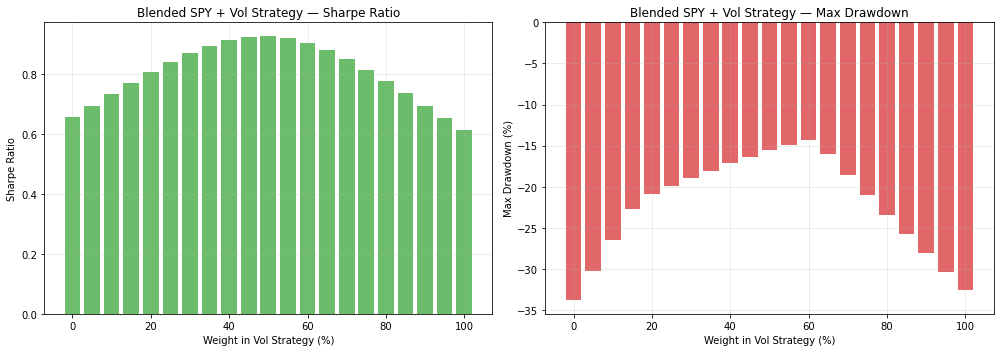


Key Blend Points:
  Weight   Sharpe      MDD
      0%    0.656   -33.8%
     10%    0.732   -26.5%
     20%    0.805   -20.8%
     50%    0.926   -15.6%
    100%    0.613   -32.6%


In [72]:
# =============================================================================
# BLEND WITH SPY (replicating paper Figure 5)
# =============================================================================
# Paper shows that even 10-20% allocation to vol strategy
# boosts a passive SPY portfolio's Sharpe by ~20%

vol_daily = results["eVRP+BoC+Sizing"]["daily"].set_index("date")["equity"]
spy_prices = df.set_index("date")["spy"]

# Align
common_dates = vol_daily.index.intersection(spy_prices.index)
vol_eq = vol_daily.loc[common_dates].values
spy_eq = (spy_prices.loc[common_dates] / spy_prices.loc[common_dates].iloc[0] * STARTING_CAPITAL).values

vol_rets = np.diff(vol_eq) / vol_eq[:-1]
spy_rets_daily = np.diff(spy_eq) / spy_eq[:-1]

weights = np.arange(0, 1.05, 0.05)
blend_sharpes = []
blend_mdds = []

for w in weights:
    blend_rets = (1 - w) * spy_rets_daily + w * vol_rets
    blend_eq = STARTING_CAPITAL * np.cumprod(1 + blend_rets)
    
    n_years = len(blend_rets) / 252
    cagr = (blend_eq[-1] / STARTING_CAPITAL) ** (1/n_years) - 1
    vol = np.std(blend_rets) * np.sqrt(252)
    sharpe = cagr / vol if vol > 0 else 0
    
    running_max = np.maximum.accumulate(blend_eq)
    mdd = ((blend_eq - running_max) / running_max).min()
    
    blend_sharpes.append(sharpe)
    blend_mdds.append(mdd)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(weights * 100, blend_sharpes, width=4, color="#2ca02c", alpha=0.7)
ax1.set_xlabel("Weight in Vol Strategy (%)")
ax1.set_ylabel("Sharpe Ratio")
ax1.set_title("Blended SPY + Vol Strategy — Sharpe Ratio")
ax1.grid(True, alpha=0.3)

ax2.bar(weights * 100, [m * 100 for m in blend_mdds], width=4, color="#d62728", alpha=0.7)
ax2.set_xlabel("Weight in Vol Strategy (%)")
ax2.set_ylabel("Max Drawdown (%)")
ax2.set_title("Blended SPY + Vol Strategy — Max Drawdown")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print key blends
print("\nKey Blend Points:")
print(f"{'Weight':>8} {'Sharpe':>8} {'MDD':>8}")
for i, w in enumerate(weights):
    if w in [0, 0.10, 0.20, 0.30, 0.50, 1.0]:
        print(f"{w*100:>7.0f}% {blend_sharpes[i]:>8.3f} {blend_mdds[i]*100:>7.1f}%")

In [73]:
# =============================================================================
# SAVE STRATEGY 4 RESULTS
# =============================================================================
import os

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

best_daily = results["eVRP+BoC+Sizing"]["daily"].copy()
best_trades = results["eVRP+BoC+Sizing"]["trades"]

# ── 1. Daily equity & returns (for portfolio construction) ──
best_daily["daily_return"] = best_daily["equity"].pct_change()
best_daily.to_csv(os.path.join(RESULTS_DIR, "vix_etn_dual_daily.csv"), index=False)
print(f"Saved daily equity → results/vix_etn_dual_daily.csv ({len(best_daily)} rows)")

# ── 2. Rebalance/trade log ──
if not best_trades.empty:
    best_trades.to_csv(os.path.join(RESULTS_DIR, "vix_etn_dual_trades.csv"), index=False)
    print(f"Saved trade log → results/vix_etn_dual_trades.csv ({len(best_trades)} rows)")

# ── 3. Synthetic per-trade results for PM compatibility ──
# Convert rebalance periods into "trades" the PM can consume
# Each period between rebalances is one "trade" with a % return
if not best_trades.empty:
    pm_trades = []
    trade_dates = best_trades["date"].values
    
    for j in range(len(trade_dates)):
        entry_date = trade_dates[j]
        exit_date = trade_dates[j+1] if j+1 < len(trade_dates) else best_daily["date"].iloc[-1]
        
        mask = (best_daily["date"] >= entry_date) & (best_daily["date"] <= exit_date)
        period = best_daily[mask]
        
        if len(period) < 2:
            continue
        
        eq_start = period["equity"].iloc[0]
        eq_end = period["equity"].iloc[-1]
        pct_return = (eq_end / eq_start) - 1
        
        pm_trades.append({
            "entry_time": entry_date,
            "exit_time": exit_date,
            "position": best_trades.iloc[j]["to_instrument"],
            "entry_price": 100,  # notional
            "exit_price": 100 * (1 + pct_return),
            "exit_reason": "rebalance",
            "risk": round(abs(pct_return) * 100, 4),
            "shares": 1,
            "gross_pnl": round(eq_end - eq_start, 2),
            "fees": round(best_trades.iloc[j]["cost"], 2),
            "net_pnl": round(eq_end - eq_start, 2),
            "equity_before": round(eq_start, 2),
            "equity": round(eq_end, 2),
        })
    
    pm_df = pd.DataFrame(pm_trades)
    pm_df.to_csv(os.path.join(RESULTS_DIR, "vix_etn_dual_pm_trades.csv"), index=False)
    print(f"Saved PM-compatible trades → results/vix_etn_dual_pm_trades.csv ({len(pm_df)} rows)")

# ── Final summary ──
m = metrics_list[-1]
print(f"\n{'='*60}")
print(f"FINAL RESULTS — {m['Strategy']}")
print(f"{'='*60}")
for k, v in m.items():
    if k == "Yearly Returns":
        continue
    elif isinstance(v, float):
        print(f"  {k:<20} {v:>10.2f}")
    else:
        print(f"  {k:<20} {v}")

Saved daily equity → results/vix_etn_dual_daily.csv (2051 rows)
Saved trade log → results/vix_etn_dual_trades.csv (694 rows)
Saved PM-compatible trades → results/vix_etn_dual_pm_trades.csv (693 rows)

FINAL RESULTS — eVRP+BoC+Sizing
  Strategy             eVRP+BoC+Sizing
  TotRet (%)               143.92
  CAGR (%)                  11.55
  Vol (%)                   18.89
  Sharpe                     0.61
  Sortino                    0.73
  MDD (%)                  -32.55
  Alpha (%)                 10.28
  Beta                       0.09
  Corr SPX (%)               8.78
  % Short Vol               91.10
  % Long Vol                 3.80
  % Cash                     5.10
  Avg Exposure (%)          17.20
  Trades               2051
  Final Equity          243907.51
  Rebalances           695
  Trades/yr                 85.20
